# PyWhy / DoWhy

PyWhy is "An Open Source Ecosystem for
Causal Machine Learning" that "build[s] and host[s] interoperable libraries, tools, and other resources spanning a variety of causal tasks and applications, connected through a common API on foundational causal operations and a focus on the end-to-end analysis process" [[PyWhy website](https://www.pywhy.org/)].


This notebook runs through a couple examples that demonstrate the functionality of their DoWhy Python library, with large portions of the code and text below coming directly from [the DoWhy documentation example notebooks](https://www.pywhy.org/dowhy/v0.11/example_notebooks/nb_index.html).

In [1]:
pip install dowhy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 49.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


# Confounding Example: Finding causal effects from observed data

Adapted from [this notebook](https://www.pywhy.org/dowhy/v0.8/example_notebooks/dowhy_confounder_example.html).



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import dowhy
from dowhy import CausalModel
import dowhy.datasets, dowhy.plotter

# Config dict to set the logging level
import logging.config
DEFAULT_LOGGING = {
    'version': 1,
    'disable_existing_loggers': False,
    'loggers': {
        '': {
            'level': 'INFO',
        },
    }
}

logging.config.dictConfig(DEFAULT_LOGGING)

Suppose you are given some data with treatment and outcome. Can you determine whether the treatment causes the outcome, or the correlation is purely due to another common cause?

## Let’s create a mystery dataset for which we need to determine whether there is a causal effect.

Creating the dataset. It is generated from either one of two models:
- **Model 1:** Treatment does cause outcome.
- **Model 2:** Treatment does not cause outcome. All observed correlation is due to a common cause.



## **TODO:** Set a random seed based on your Net-ID! (but don't look at the true causal effect yet 👀)

In [3]:
import random

net_id = 'ls5788'
random.seed(net_id)
true_effect = 1 if random.uniform(0, 1) > 0.5 else 0

In [4]:
# generate data from the chosen model
data_dict = dowhy.datasets.xy_dataset(10000, effect=true_effect,
                                      num_common_causes=1,
                                      sd_error=0.2)
df = data_dict['df']
print(df[["Treatment", "Outcome", "w0"]].head())

   Treatment    Outcome        w0
0   3.059394   5.684753 -3.029832
1   8.680756  17.317565  2.689364
2   6.139076  12.361053  0.211580
3   8.880339  17.993523  2.919137
4   8.455431  16.365272  2.264136


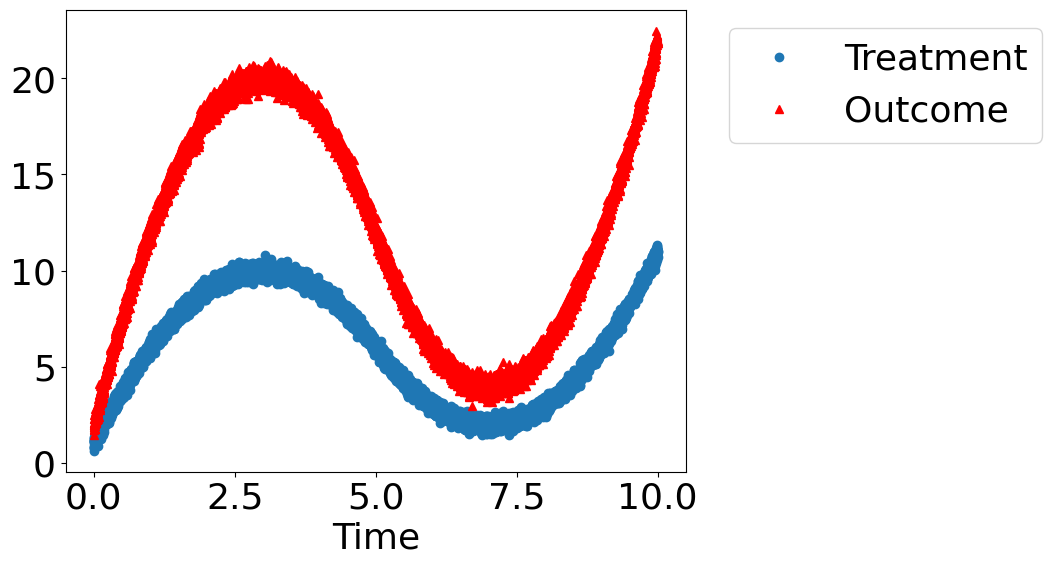

In [5]:
dowhy.plotter.plot_treatment_outcome(df[data_dict["treatment_name"]], df[data_dict["outcome_name"]],
                             df[data_dict["time_val"]])

## Using DoWhy to resolve the mystery: Does Treatment cause Outcome?

### STEP 1: Model the problem as a causal graph

Initializing the causal model.

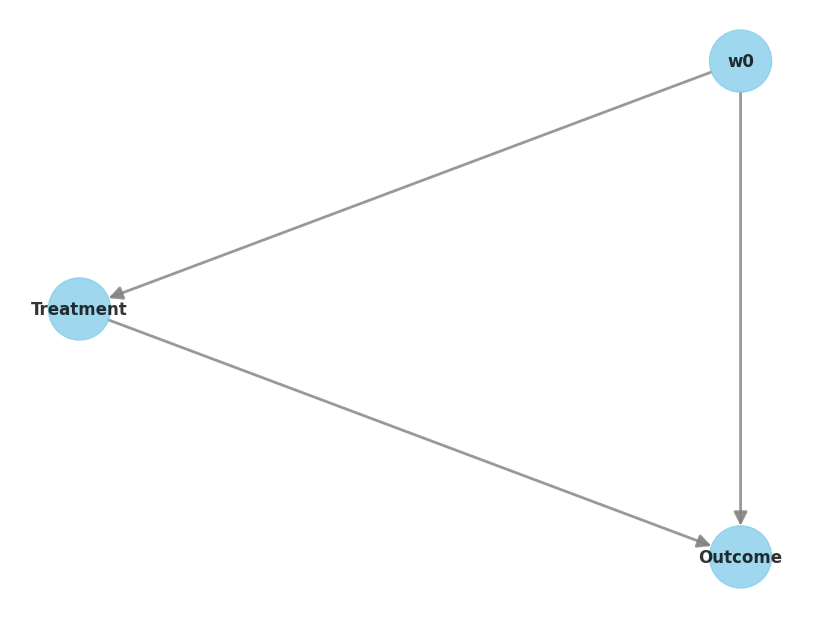

In [6]:
model= CausalModel(
    data=df,
    treatment=data_dict["treatment_name"],
    outcome=data_dict["outcome_name"],
    common_causes=data_dict["common_causes_names"],
)
model.view_model(layout="dot")

### STEP 2: Identify causal effect using properties of the formal causal graph

Identify the causal effect using properties of the causal graph. Here DoWhy will automatically control for `w0` as a confounder since we listed `w0` as a possible confounder — a "common cause." This step is called **identification** of the causal effect. We find out, according to our assumptions, if we can or cannot estimate the effect from the data.

In [7]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                     
────────────(E[Outcome|w0])
d[Treatment]               
Estimand assumption 1, Unconfoundedness: If U→{Treatment} and U→Outcome then P(Outcome|Treatment,w0,U) = P(Outcome|Treatment,w0)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                     
────────────(E[Outcome|w0])
d[Treatment]               
Estimand assumption 1, Unconfoundedness: If U→{Treatment} and U→Outcome then P(Outcome|Treatment,w0,U) = P(Outcome|Treatment,w0)



### STEP 3: Estimate the causal effect

Once we have identified the estimand, we can use any statistical method to estimate the causal effect.

Let’s use Linear Regression for simplicity.

Causal Estimate is 0.984579682296947


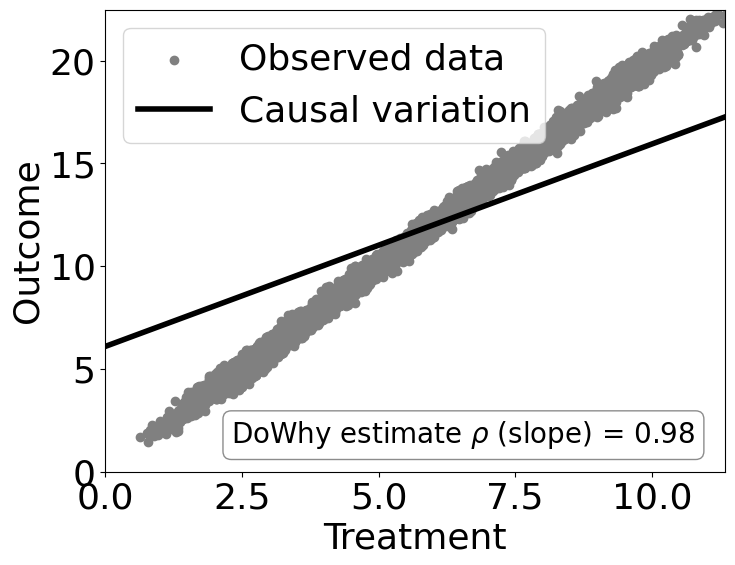

In [8]:
estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.linear_regression")
print("Causal Estimate is " + str(estimate.value))

# Plot Slope of line between treamtent and outcome =causal effect
dowhy.plotter.plot_causal_effect(estimate, df[data_dict["treatment_name"]], df[data_dict["outcome_name"]])

## **TODO:** What is the DoWhy estimate of your casual effect? Is it correct?

In [9]:
print("DoWhy estimate is " + str(estimate.value))
print (f"Actual true causal effect was {true_effect}")

DoWhy estimate is 0.984579682296947
Actual true causal effect was 1


The estimate is 1.02, meaning that 1 unit of increase in treatment causes the outcome to increase 1.02 unit. The result is correct since the actual true causal effect is 1.

### Step 4: Refuting the estimate

We can also refute the estimate to check its robustness to assumptions (AKA sensitivity analysis).

> Is the effect robust to adding another common cause variable?



In [10]:
res_random=model.refute_estimate(identified_estimand, estimate, method_name="random_common_cause")
print(res_random)

Refute: Add a random common cause
Estimated effect:0.984579682296947
New effect:0.9845717252875307
p value:0.86



Yes. Since the p-value is large, we don't regect H0. The change is not significant.

> Is the effect robust to replacing the treatment with a random (placebo) variable?

**NOTE: what would we want to happen here?**

In [11]:
res_placebo=model.refute_estimate(identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute")
print(res_placebo)

Refute: Use a Placebo Treatment
Estimated effect:0.984579682296947
New effect:3.785852763249054e-05
p value:0.9199999999999999



Yes. Since the p-value is large, we don't regect H0. The change is not significant.

> Is the effect robust to removing a random subset of the data?

In [12]:
res_subset=model.refute_estimate(identified_estimand, estimate,
        method_name="data_subset_refuter", subset_fraction=0.9)
print(res_subset)

Refute: Use a subset of data
Estimated effect:0.984579682296947
New effect:0.983973177873733
p value:0.84



Yes. Since the p-value is large, we don't regect H0. The change is not significant.

# DoWhy example on the IHDP (Infant Health and Development Program) dataset

Adapted from [this notebook](https://www.pywhy.org/dowhy/v0.8/example_notebooks/dowhy_ihdp_data_example.html).

In [13]:
data= pd.read_csv("https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/master/datasets/IHDP/csv/ihdp_npci_1.csv", header = None)
col =  ["treatment", "y_factual", "y_cfactual", "mu0", "mu1" ,]
for i in range(1,26):
    col.append("x"+str(i))
data.columns = col
data = data.astype({"treatment":'bool'}, copy=False)
data.head()

,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,True,5.599916,4.318780,3.268256,6.854457,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,False,6.875856,7.856495,6.636059,7.562718,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,False,2.996273,6.633952,1.570536,6.121617,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,False,1.366206,5.697239,1.244738,5.889125,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,False,1.963538,6.202582,1.685048,6.191994,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0


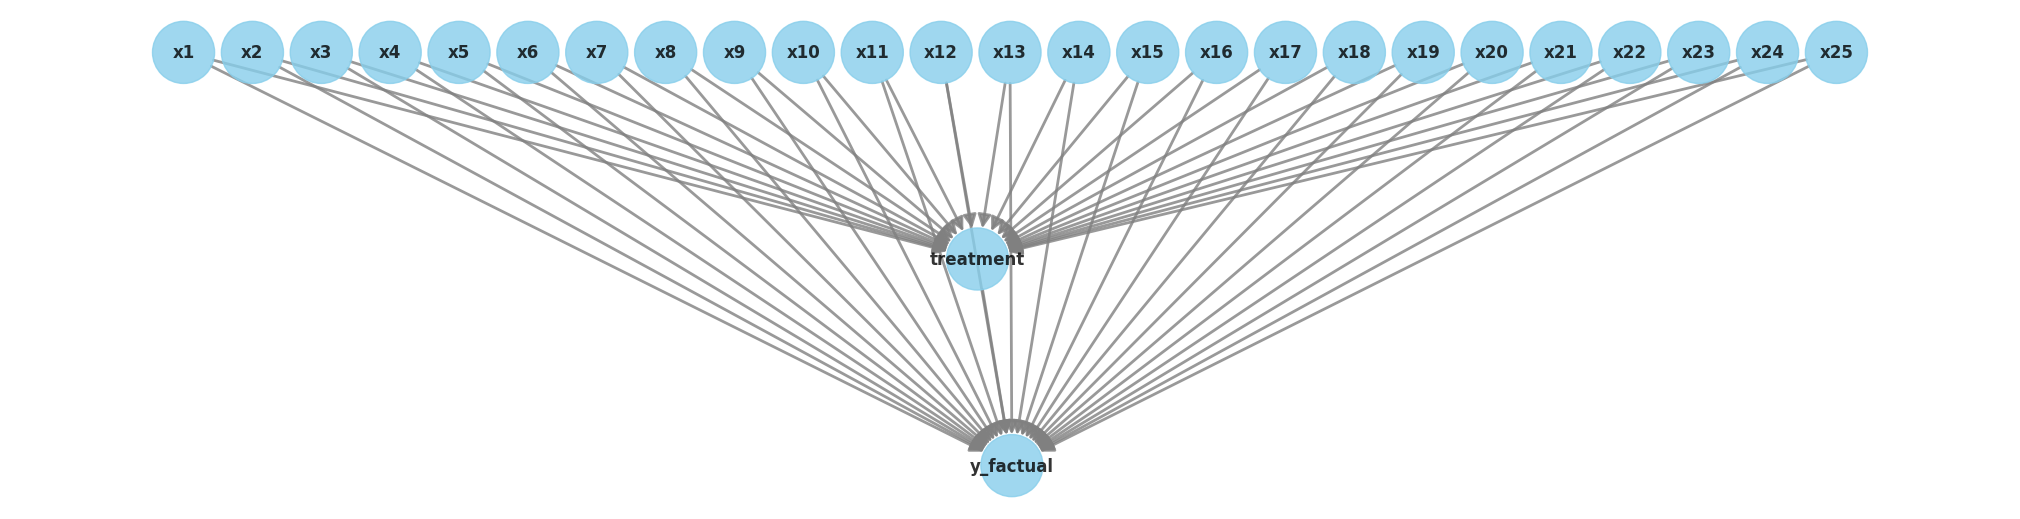

In [14]:
# Create a causal model from the data and given common causes.
model=CausalModel(
        data = data,
        treatment='treatment',
        outcome='y_factual',
        common_causes=["x"+str(i) for  i in range(1,26)]
        )
model.view_model('dot', size=(20, 5))

## **TODO:** describe what assumptions are being made in this graph

> Answer here:
All variables are common causes (confounders).
There are no unobserved confounders.
No other causal pathways exist.

## Next we do identification again:

In [15]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True, method_name="maximal-adjustment")
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[y_factual|x1,x21,x25,x12,x15,x9,x11,x10,x20,x6,x16,x5,x23,x3,x2 ↪
d[treatment]                                                                   ↪

↪                                        
↪ 2,x24,x19,x14,x7,x13,x18,x8,x4,x2,x17])
↪                                        
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→y_factual then P(y_factual|treatment,x1,x21,x25,x12,x15,x9,x11,x10,x20,x6,x16,x5,x23,x3,x22,x24,x19,x14,x7,x13,x18,x8,x4,x2,x17,U) = P(y_factual|treatment,x1,x21,x25,x12,x15,x9,x11,x10,x20,x6,x16,x5,x23,x3,x22,x24,x19,x14,x7,x13,x18,x8,x4,x2,x17)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    

## Estimate using different methods

Don't worry about knowing each of these methods. The point here is that there are many ways to estimate, and each of these are exactly that — estimates!  

> Using linear regression

In [16]:
# Estimate the causal effect and compare it with Average Treatment Effect
estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.linear_regression", test_significance=True
)

print(estimate)

print("Causal Estimate is " + str(estimate.value))
data_1 = data[data["treatment"]==1]
data_0 = data[data["treatment"]==0]

print("ATE", np.mean(data_1["y_factual"])- np.mean(data_0["y_factual"]))


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[y_factual|x1,x21,x25,x12,x15,x9,x11,x10,x20,x6,x16,x5,x23,x3,x2 ↪
d[treatment]                                                                   ↪

↪                                        
↪ 2,x24,x19,x14,x7,x13,x18,x8,x4,x2,x17])
↪                                        
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→y_factual then P(y_factual|treatment,x1,x21,x25,x12,x15,x9,x11,x10,x20,x6,x16,x5,x23,x3,x22,x24,x19,x14,x7,x13,x18,x8,x4,x2,x17,U) = P(y_factual|treatment,x1,x21,x25,x12,x15,x9,x11,x10,x20,x6,x16,x5,x23,x3,x22,x24,x19,x14,x7,x13,x18,x8,x4,x2,x17)

## Realized estimand
b: y_factual~treatment+x1+x21+x25+x12+x15+x9+x11+x10+x20+x6+x16+x5+x23+x3+x22+x24+x19+x14+x7+x13+x18+x8+x4+x2+x17
Target units: ate

## Esti

> Using propensity score matching

In [17]:
estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.propensity_score_matching"
)

print("Causal Estimate is " + str(estimate.value))

print("ATE", np.mean(data_1["y_factual"])- np.mean(data_0["y_factual"]))


Causal Estimate is 3.9727311622191595
ATE 4.021121012430829


> Using propensity score stratification

In [18]:
estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.propensity_score_stratification", method_params={'num_strata':50, 'clipping_threshold':5}
)

print("Causal Estimate is " + str(estimate.value))
print("ATE", np.mean(data_1["y_factual"])- np.mean(data_0["y_factual"]))



Causal Estimate is 3.3625443135345345
ATE 4.021121012430829


> Using propensity score weighting

In [19]:
estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.propensity_score_weighting"
)

print("Causal Estimate is " + str(estimate.value))

print("ATE", np.mean(data_1["y_factual"])- np.mean(data_0["y_factual"]))


Causal Estimate is 4.028653382811926
ATE 4.021121012430829


## Refuting our estimates to test robustness (same as before)

In [20]:
refute_results=model.refute_estimate(identified_estimand, estimate,
        method_name="random_common_cause")
print(refute_results)

Refute: Add a random common cause
Estimated effect:4.028653382811926
New effect:4.028653382811925
p value:1.0



In [21]:
res_placebo=model.refute_estimate(identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute")
print(res_placebo)

Refute: Use a Placebo Treatment
Estimated effect:4.028653382811926
New effect:-0.4276717161636666
p value:0.06



In [22]:
res_subset=model.refute_estimate(identified_estimand, estimate,
        method_name="data_subset_refuter", subset_fraction=0.9)
print(res_subset)

Refute: Use a subset of data
Estimated effect:4.028653382811926
New effect:4.030414207005933
p value:1.0



# **TODO:** create or download your own dataset and estimate an effect like we did above! Describe what you find.

In [29]:
pip install ucimlrepo

In [30]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)

# data (as pandas dataframes)
X = real_estate_valuation.data.features
y = real_estate_valuation.data.targets

# metadata
print(real_estate_valuation.metadata)

# variable information
print(real_estate_valuation.variables)

{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

In [60]:
df = pd.DataFrame(X)
df["Y"] = y
df.head()
confounders = df.drop(columns=["X4 number of convenience stores","Y"])

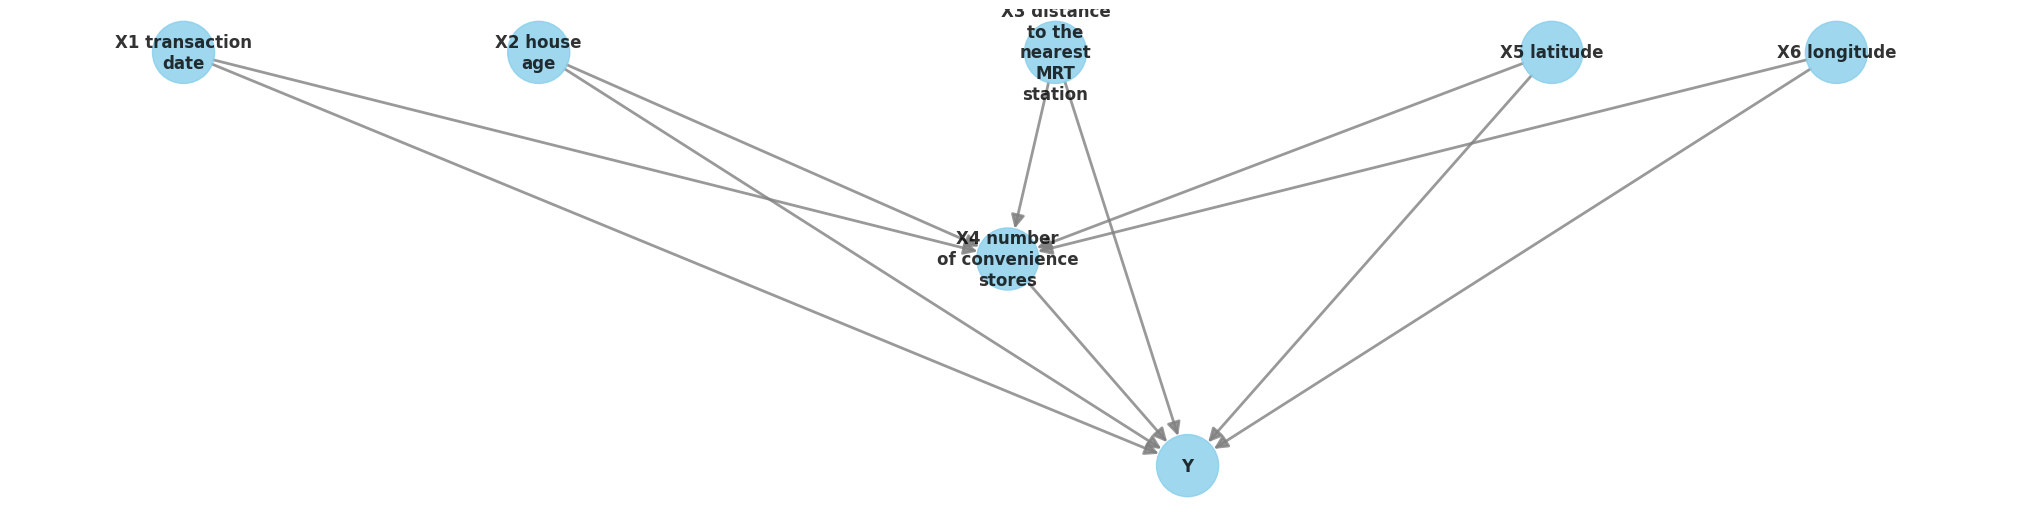

In [61]:
model=CausalModel(
        data = df,
        treatment='X4 number of convenience stores',
        outcome='Y',
        common_causes=confounders.columns.tolist()
        )
model.view_model('dot', size=(20, 5))

In [62]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True, method_name="maximal-adjustment")
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
                d                                                              ↪
──────────────────────────────────(E[Y|X3 distance to the nearest MRT station, ↪
d[X4 number of convenience stores]                                             ↪

↪                                                            
↪ X5 latitude,X2 house age,X6 longitude,X1 transaction date])
↪                                                            
Estimand assumption 1, Unconfoundedness: If U→{X4 number of convenience stores} and U→Y then P(Y|X4 number of convenience stores,X3 distance to the nearest MRT station,X5 latitude,X2 house age,X6 longitude,X1 transaction date,U) = P(Y|X4 number of convenience stores,X3 distance to the nearest MRT station,X5 latitude,X2 house age,X6 longitude,X1 transaction date)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: 

In [63]:
# Estimate the causal effect and compare it with Average Treatment Effect
estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.linear_regression", test_significance=True
)

print(estimate)
ate_value = estimate.value


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
                d                                                              ↪
──────────────────────────────────(E[Y|X3 distance to the nearest MRT station, ↪
d[X4 number of convenience stores]                                             ↪

↪                                                            
↪ X5 latitude,X2 house age,X6 longitude,X1 transaction date])
↪                                                            
Estimand assumption 1, Unconfoundedness: If U→{X4 number of convenience stores} and U→Y then P(Y|X4 number of convenience stores,X3 distance to the nearest MRT station,X5 latitude,X2 house age,X6 longitude,X1 transaction date,U) = P(Y|X4 number of convenience stores,X3 distance to the nearest MRT station,X5 latitude,X2 house age,X6 longitude,X1 transaction date)

## Realized estimand
b: Y~X4 number of convenie

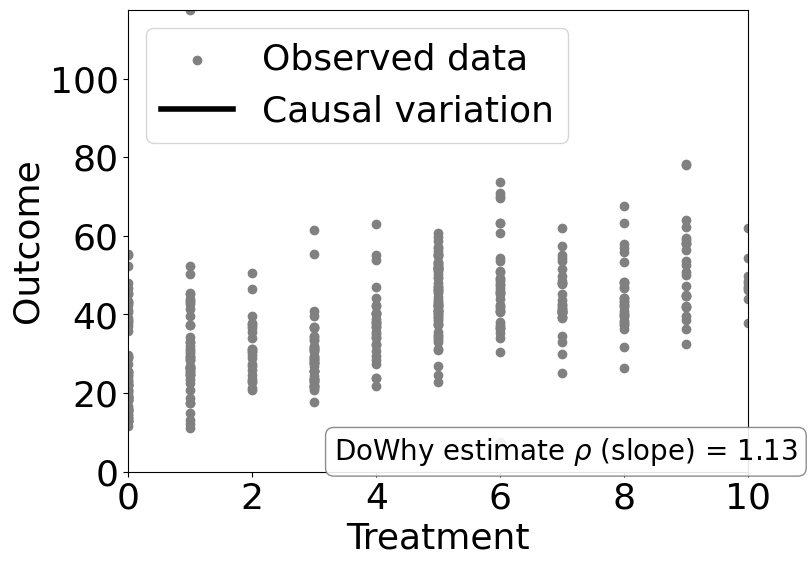

In [64]:
dowhy.plotter.plot_causal_effect(estimate, df["X4 number of convenience stores"], df["Y"])

In [65]:
refute_results=model.refute_estimate(identified_estimand, estimate,
        method_name="random_common_cause")
print(refute_results)

Refute: Add a random common cause
Estimated effect:1.1332769046488949
New effect:1.1336642422992276
p value:0.9



In [66]:
res_placebo=model.refute_estimate(identified_estimand, estimate,
        method_name="placebo_treatment_refuter", placebo_type="permute")
print(res_placebo)

Refute: Use a Placebo Treatment
Estimated effect:1.1332769046488949
New effect:0.011954560906311187
p value:0.98



In [67]:
res_subset=model.refute_estimate(identified_estimand, estimate,
        method_name="data_subset_refuter", subset_fraction=0.9)
print(res_subset)

Refute: Use a subset of data
Estimated effect:1.1332769046488949
New effect:1.1346090453049542
p value:0.92



I tried to estimate the effect of number of convenience stores on New TaiPei City's house price. I found that X1, X2, X3, X5, and X6 are all confoudners. We can only use backdoor method to estimate the effect. What's more, the estimated effect is about 1.13, meaning that if the number of convenience stores increase by 1, the house price of unit area increase by about 11300 $NTD/ Ping. The effect is robuts enough.